# Week 8 — per-layer QAT sweep: accuracy and latency

Plots the results of the **18-layer INT8 QAT sensitivity sweep** (one layer quantised and
fine-tuned at a time, everything else frozen), with the project's earlier baselines drawn
in as reference lines.

**Source of every number**

| what | file |
|---|---|
| the 18 sweep rows | `experiments/week8_layer_sweep/results_master_malmo_h100.csv` |
| V0 / V1 frozen-baseline pair | `experiments/week8_frozen_qat/RESULTS.md` |
| FP32 / FP16 / PTQ / QAT precision ladder | `README.md` §3 |

**One caveat that shapes the whole notebook.** Accuracy is comparable across *every* row
here — one eval harness throughout (full val, 6,449 images, `conf=0.001`, `max_dets=300`,
imgsz 640, pycocotools `COCOeval bbox`). Latency is **not**: the sweep was timed GPU-only
on an **H100 with CUDA graphs**, while the baselines were timed on an **A100, kernel-median,
no CUDA graph**. Those two groups are therefore never drawn on the same axis below — see
Figure 2.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Locate the repo root whether the notebook is run from notebooks/ or from the root.
REPO = Path.cwd()
while not (REPO / "experiments" / "week8_layer_sweep").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent

CSV = REPO / "experiments" / "week8_layer_sweep" / "results_master_malmo_h100.csv"
OUT = REPO / "reports" / "week8_layer_sweep"
OUT.mkdir(parents=True, exist_ok=True)

raw = pd.read_csv(CSV)
sweep = raw[raw["status"] == "ok"].copy()
sweep["idx"] = sweep["layer"].str.split(".").str[1].astype(int)
sweep = sweep.sort_values("idx").reset_index(drop=True)

skipped = raw.loc[raw["status"] != "ok", "layer"].tolist()
print(f"trained layers : {len(sweep)}")
print(f"skipped        : {len(skipped)}  ({', '.join(skipped)})")
print(f"               reason: no_trainable_params - Concat/Upsample nodes, expected")
print()
print(sweep[["layer", "mAP50", "mAP50-95", "latency_graph_ms",
             "latency_no_graph_ms", "epochs_trained"]].to_string(index=False))

trained layers : 18
skipped        : 6  (model.11, model.12, model.14, model.15, model.18, model.21)
               reason: no_trainable_params - Concat/Upsample nodes, expected

   layer    mAP50  mAP50-95  latency_graph_ms  latency_no_graph_ms  epochs_trained
 model.0 0.703843  0.498162          0.743713             0.958725             5.0
 model.1 0.734067  0.534272          0.758179             1.000090             6.0
 model.2 0.751643  0.556760          0.758049             0.966019             4.0
 model.3 0.765701  0.576864          0.756805             0.960777             6.0
 model.4 0.794694  0.620542          0.761497             0.998596             6.0
 model.5 0.782331  0.599382          0.744308             0.956619             5.0
 model.6 0.851089  0.652468          0.759163             0.969986             6.0
 model.7 0.809695  0.616783          0.755325             0.966808             5.0
 model.8 0.859061  0.667494          0.765636             1.002610        

## Baselines

`V0` and `V1` are the week-8 frozen-baseline pair that the sweep is measured against:

- **V0** — COCO `yolo26n.pt` with backbone+neck frozen (`freeze=23`), head-only training on
  the surgical data, deployed as an **FP16** engine.
- **V1** — that same frozen model with calibrate-only INT8 QAT (`mtq.quantize` + max
  calibration on 128 frames, **zero** training iterations), deployed as an **INT8** engine.
  This is the sweep's zero point: what INT8 costs before any fine-tuning recovers it.

`FP32 / FP16 / INT8 PTQ / INT8 QAT` are the fully-trained precision ladder from §3 of the
README — a different, much stronger model, included to show how far single-layer QAT is
from the deployable numbers.

In [2]:
# All accuracy on one harness. Latency: A100, kernel-median, batch=1, no CUDA graph.
BASELINES = pd.DataFrame([
    # name,                       mAP50,  mAP50-95, kernel_ms, group
    ("V0  frozen baseline (FP16)", 0.7419, 0.5313, 1.253, "week8"),
    ("V1  frozen + 0-iter QAT (INT8)", 0.6906, 0.4892, 1.503, "week8"),
    ("FP32 engine (V2)",           0.9325, 0.7747, 2.019, "ladder"),
    ("FP16 engine (V3)",           0.9327, 0.7748, 1.137, "ladder"),
    ("INT8 PTQ (V4)",              0.9282, 0.7571, 1.091, "ladder"),
    ("INT8 QAT (V6)",              0.9321, 0.7644, 1.397, "ladder"),
], columns=["name", "mAP50", "mAP50-95", "kernel_ms", "group"])

V0_50_95, V1_50_95 = 0.5313, 0.4892
V0_50,    V1_50    = 0.7419, 0.6906
FP32_50_95, FP16_50_95 = 0.7747, 0.7748
FP32_50,    FP16_50    = 0.9325, 0.9327

best = sweep.loc[sweep["mAP50-95"].idxmax()]
print(BASELINES.to_string(index=False))
print()
print(f"best sweep layer : {best['layer']}  mAP50-95 {best['mAP50-95']:.4f}  "
      f"mAP50 {best['mAP50']:.4f}")
print(f"  vs V1 (zero point) : {best['mAP50-95'] - V1_50_95:+.4f}")
print(f"  vs V0 (FP16)       : {best['mAP50-95'] - V0_50_95:+.4f}")
print(f"  gap to FP32 closed : {(best['mAP50-95'] - V1_50_95) / (FP32_50_95 - V1_50_95):.1%}")

                          name  mAP50  mAP50-95  kernel_ms  group
    V0  frozen baseline (FP16) 0.7419    0.5313      1.253  week8
V1  frozen + 0-iter QAT (INT8) 0.6906    0.4892      1.503  week8
              FP32 engine (V2) 0.9325    0.7747      2.019 ladder
              FP16 engine (V3) 0.9327    0.7748      1.137 ladder
                 INT8 PTQ (V4) 0.9282    0.7571      1.091 ladder
                 INT8 QAT (V6) 0.9321    0.7644      1.397 ladder

best sweep layer : model.8  mAP50-95 0.6675  mAP50 0.8591
  vs V1 (zero point) : +0.1783
  vs V0 (FP16)       : +0.1362
  gap to FP32 closed : 62.4%


## Figure 1 — Accuracy per quantised layer

One bar per layer, ranked. Bars are coloured by whether QAT on that layer beat the **V0
FP16** frozen baseline: green means quantising it and training it back was worth more than
it cost, red means it was not.

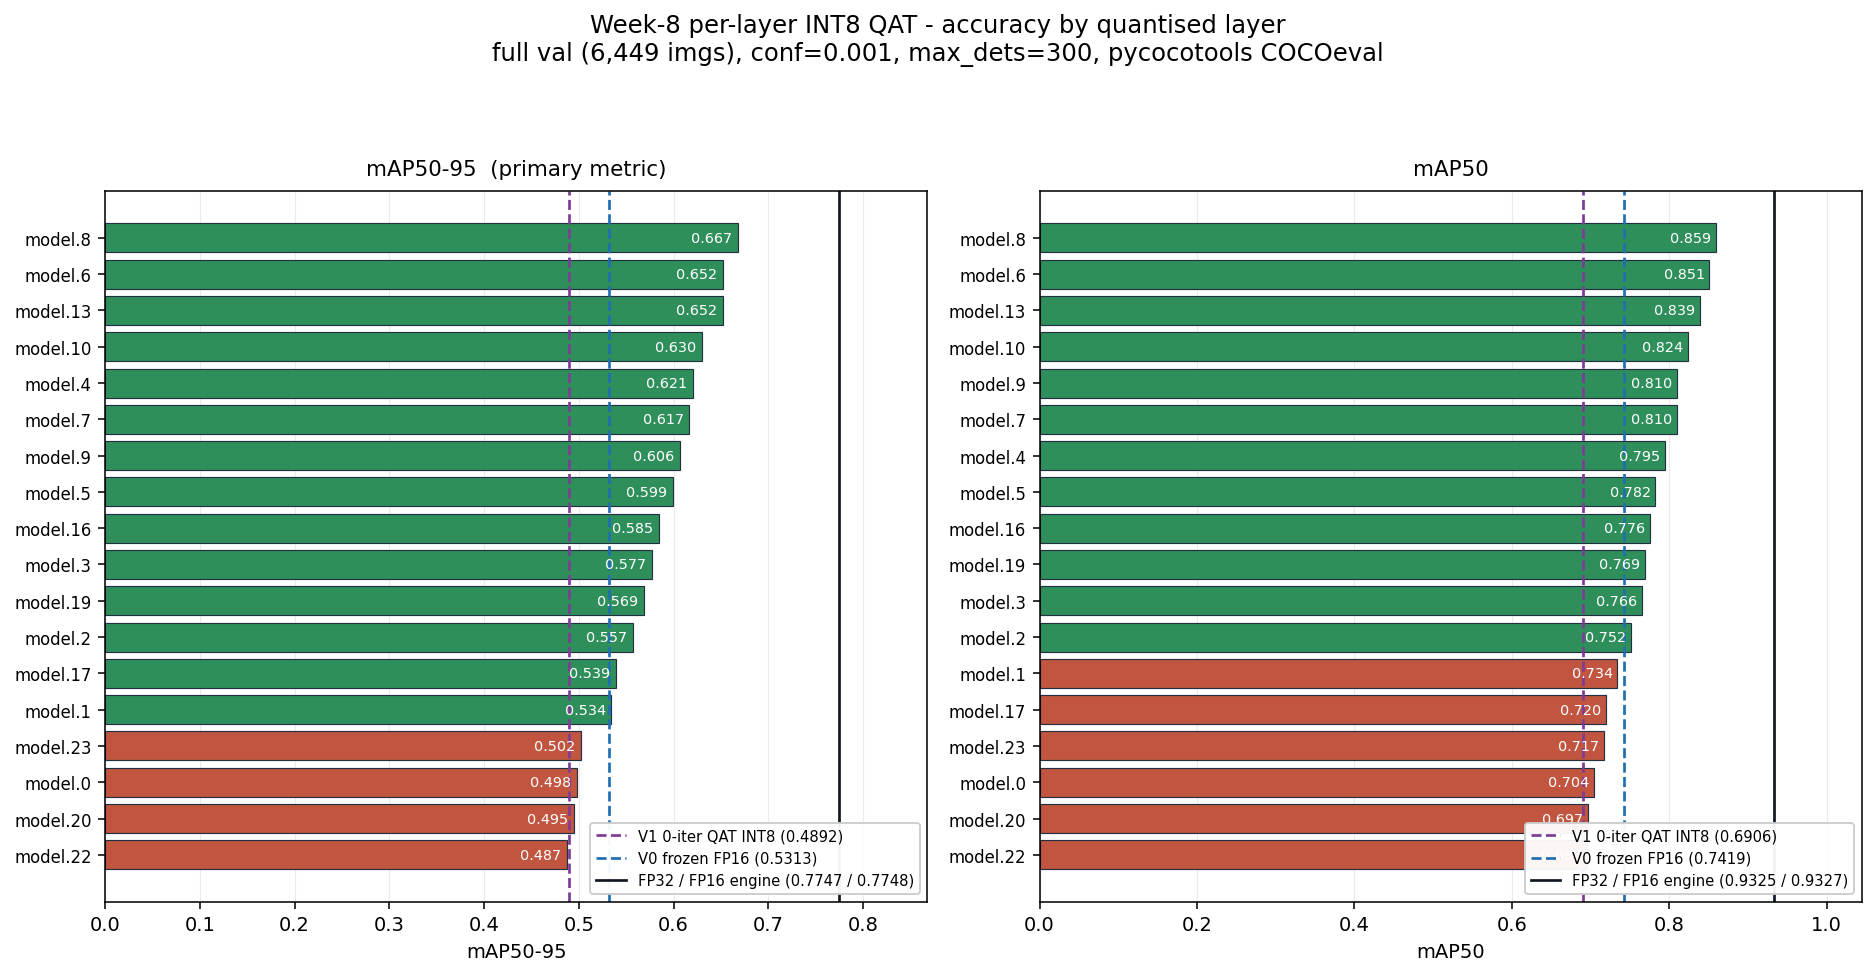

In [3]:
STYLE = dict(edgecolor="#22303f", linewidth=0.6)
GREEN, RED, GREY = "#2f8f5b", "#c1553f", "#8c98a4"

def accuracy_panel(ax, col, v0, v1, fp32, fp16, title, xlabel):
    d = sweep.sort_values(col, ascending=True)
    colors = [GREEN if v > v0 else RED for v in d[col]]
    ypos = range(len(d))
    ax.barh(list(ypos), d[col], color=colors, **STYLE)
    ax.set_yticks(list(ypos))
    ax.set_yticklabels(d["layer"], fontsize=8.5)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11, pad=8)

    for y, v in zip(ypos, d[col]):
        ax.text(v - 0.006, y, f"{v:.3f}", va="center", ha="right",
                fontsize=7.4, color="white", fontweight="medium")

    # reference lines. FP32 and FP16 differ by ~0.0001 - draw one combined line.
    ax.axvline(v1, color="#7d3c98", ls="--", lw=1.4,
               label=f"V1 0-iter QAT INT8 ({v1:.4f})")
    ax.axvline(v0, color="#1f6fb2", ls="--", lw=1.4,
               label=f"V0 frozen FP16 ({v0:.4f})")
    ax.axvline(fp32, color="#111820", ls="-", lw=1.4,
               label=f"FP32 / FP16 engine ({fp32:.4f} / {fp16:.4f})")

    ax.set_xlim(0, max(fp32, fp16) * 1.12)
    ax.grid(axis="x", alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    ax.legend(loc="lower right", fontsize=7.6, framealpha=0.95)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 7.0))
accuracy_panel(axes[0], "mAP50-95", V0_50_95, V1_50_95, FP32_50_95, FP16_50_95,
               "mAP50-95  (primary metric)", "mAP50-95")
accuracy_panel(axes[1], "mAP50", V0_50, V1_50, FP32_50, FP16_50,
               "mAP50", "mAP50")
fig.suptitle("Week-8 per-layer INT8 QAT - accuracy by quantised layer\n"
             "full val (6,449 imgs), conf=0.001, max_dets=300, pycocotools COCOeval",
             fontsize=12.5, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(OUT / "fig1_accuracy_by_layer.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Mid/late backbone — `model.4` through `model.10`, plus `model.13` —
carries essentially all the recoverable accuracy. The stem (`model.0`) and the head
(`model.20/22/23`) buy nothing: those four sit **below** the V0 FP16 line, i.e. quantising
them costs more than six epochs of training them back recovers. `model.22` is fractionally
negative even against the calibrate-only V1 zero point.

Every layer clears V1, so QAT always beats no-fine-tuning — but only the green bars clear
FP16, which is the bar that actually matters for deployment.

## Figure 2 — Latency

**Read the two panels separately — they are different measurement harnesses and the axes
are not interchangeable.**

- **Left:** the 18 sweep engines, timed GPU-only on an **H100 with CUDA graphs**, all
  inside one exclusive-GPU window, so they are comparable *to each other*.
- **Right:** the baselines, kernel-median on an **A100 with no CUDA graph**. Different GPU,
  different harness — shown for scale only.

The left panel's y-axis is zoomed to the data range; on a 0-based axis the 18 bars would be
visually identical, which is itself the result.

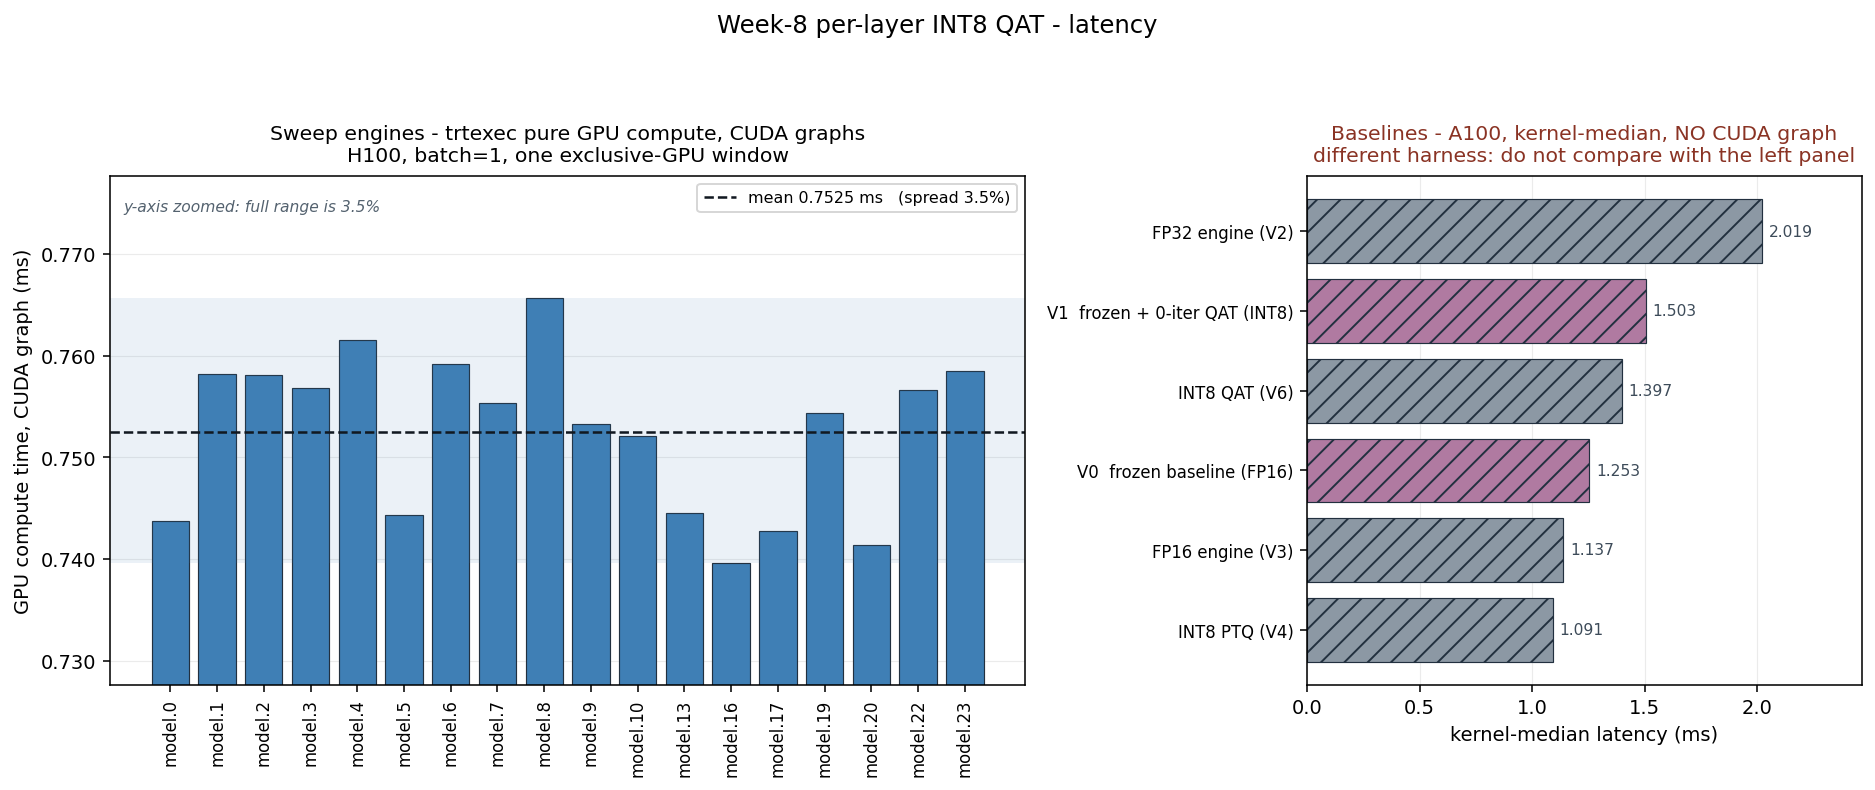

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6),
                         gridspec_kw={"width_ratios": [1.65, 1]})

# ---- left: sweep, H100 GPU-only + CUDA graphs -------------------------------
ax = axes[0]
g = sweep["latency_graph_ms"]
ax.bar(sweep["layer"], g, color="#3f7fb5", **STYLE)
mean, lo, hi = g.mean(), g.min(), g.max()
ax.axhline(mean, color="#111820", ls="--", lw=1.3,
           label=f"mean {mean:.4f} ms   (spread {(hi - lo) / lo:.1%})")
ax.axhspan(lo, hi, color="#3f7fb5", alpha=0.10, lw=0)
ax.set_ylim(lo - 0.012, hi + 0.012)
ax.set_ylabel("GPU compute time, CUDA graph (ms)")
ax.set_title("Sweep engines - trtexec pure GPU compute, CUDA graphs\n"
             "H100, batch=1, one exclusive-GPU window", fontsize=10.5, pad=8)
ax.tick_params(axis="x", rotation=90, labelsize=8.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.grid(axis="y", alpha=0.25, lw=0.6)
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=8.2)
ax.text(0.015, 0.955, "y-axis zoomed: full range is 3.5%", va="top",
        transform=ax.transAxes, fontsize=8, style="italic", color="#54626f")

# ---- right: baselines, A100 kernel-median, no CUDA graph --------------------
ax = axes[1]
b = BASELINES.sort_values("kernel_ms")
colors = ["#8c98a4" if grp == "ladder" else "#b07aa1" for grp in b["group"]]
ax.barh(range(len(b)), b["kernel_ms"], color=colors, hatch="//", **STYLE)
ax.set_yticks(range(len(b)))
ax.set_yticklabels(b["name"], fontsize=8.5)
for y, v in enumerate(b["kernel_ms"]):
    ax.text(v + 0.03, y, f"{v:.3f}", va="center", fontsize=8, color="#3d4b59")
ax.set_xlabel("kernel-median latency (ms)")
ax.set_xlim(0, b["kernel_ms"].max() * 1.22)
ax.set_title("Baselines - A100, kernel-median, NO CUDA graph\n"
             "different harness: do not compare with the left panel",
             fontsize=10.5, pad=8, color="#8a3324")
ax.grid(axis="x", alpha=0.25, lw=0.6)
ax.set_axisbelow(True)

fig.suptitle("Week-8 per-layer INT8 QAT - latency", fontsize=12.5, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT / "fig2_latency.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Nothing — deliberately. Across the 18 sweep engines the CUDA-graph GPU
compute time spans 0.7396–0.7656 ms, a **3.5% spread**, and it is uncorrelated with which
layer was quantised (Figure 3 makes that explicit). At this precision the latency axis does
not discriminate between layers, so the ranking in Figure 1 is the only usable signal.

The right panel is where the project's real latency story lives: INT8 PTQ is the floor
(1.091 ms), FP16 is 4% behind it (1.137 ms), and full INT8 QAT is *slower* than both
(1.397 ms) because explicit-Q/DQ INT8 builds more kernels and this model is launch-bound,
not compute-bound.

## Figure 3 — The two axes against each other

If layer choice traded accuracy against latency there would be a clear slope here. There is
not: the points span 0.18 mAP50-95 vertically and 0.026 ms horizontally, and the weak
positive correlation that does appear (`r = +0.27`) is well below the 5% significance
threshold for n=18 (|r| > 0.468) — i.e. indistinguishable from noise at this sample size.

Pearson correlation, CUDA-graph latency vs mAP50-95: r = +0.273
  n = 18, two-tailed 5% critical |r| = 0.468  ->  NOT significant
accuracy range : 0.4874 - 0.6675  (0.1801 span)
latency range  : 0.7396 - 0.7656 ms  (0.0260 ms span)


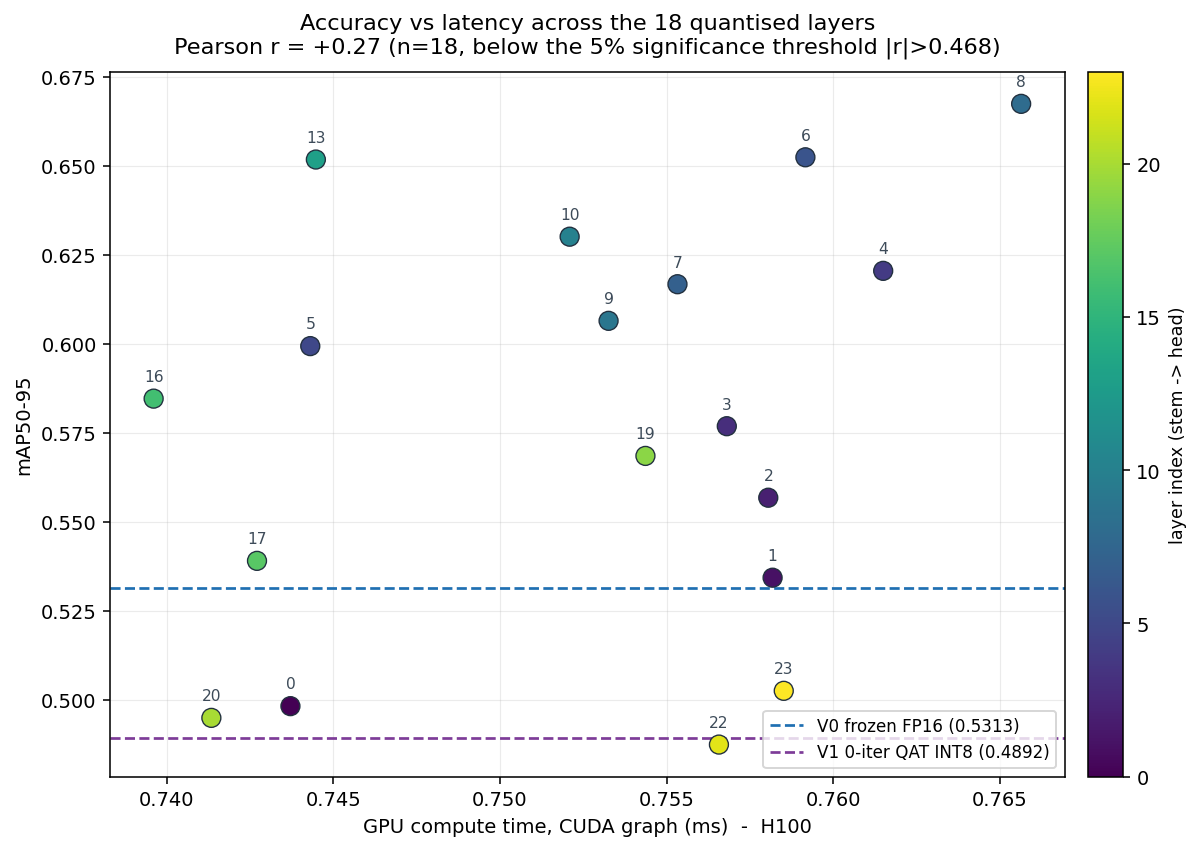

In [5]:
r = sweep["latency_graph_ms"].corr(sweep["mAP50-95"])
R_CRIT_N18_P05 = 0.468   # two-tailed 5% critical value of Pearson r at n=18 (df=16)

print(f"Pearson correlation, CUDA-graph latency vs mAP50-95: r = {r:+.3f}")
print(f"  n = {len(sweep)}, two-tailed 5% critical |r| = {R_CRIT_N18_P05}"
      f"  ->  {'significant' if abs(r) > R_CRIT_N18_P05 else 'NOT significant'}")
print(f"accuracy range : {sweep['mAP50-95'].min():.4f} - {sweep['mAP50-95'].max():.4f}"
      f"  ({sweep['mAP50-95'].max() - sweep['mAP50-95'].min():.4f} span)")
print(f"latency range  : {sweep['latency_graph_ms'].min():.4f} - "
      f"{sweep['latency_graph_ms'].max():.4f} ms"
      f"  ({sweep['latency_graph_ms'].max() - sweep['latency_graph_ms'].min():.4f} ms span)")

fig, ax = plt.subplots(figsize=(9.2, 6.2))

sc = ax.scatter(sweep["latency_graph_ms"], sweep["mAP50-95"],
                c=sweep["idx"], cmap="viridis", s=95, zorder=3,
                edgecolor="#22303f", linewidth=0.7)
for _, row in sweep.iterrows():
    ax.annotate(row["layer"].replace("model.", ""),
                (row["latency_graph_ms"], row["mAP50-95"]),
                textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=8, color="#3d4b59")

ax.axhline(V0_50_95, color="#1f6fb2", ls="--", lw=1.4,
           label=f"V0 frozen FP16 ({V0_50_95:.4f})")
ax.axhline(V1_50_95, color="#7d3c98", ls="--", lw=1.4,
           label=f"V1 0-iter QAT INT8 ({V1_50_95:.4f})")

ax.set_xlabel("GPU compute time, CUDA graph (ms)  -  H100")
ax.set_ylabel("mAP50-95")
ax.set_title("Accuracy vs latency across the 18 quantised layers\n"
             f"Pearson r = {r:+.2f} (n=18, below the 5% significance threshold "
             f"|r|>{R_CRIT_N18_P05})",
             fontsize=11.5, pad=10)
ax.grid(alpha=0.25, lw=0.6)
ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=8.6)
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("layer index (stem -> head)", fontsize=9)

fig.tight_layout()
fig.savefig(OUT / "fig3_accuracy_vs_latency.png", dpi=140, bbox_inches="tight")
plt.show()

## Takeaways

1. **Layer choice matters for accuracy, not for latency.** `model.8` recovers 62.4% of the
   V1 → FP32 gap; `model.22` recovers none. Latency moves 3.5% across all 18 and is
   uncorrelated with the layer.
2. **Four layers are net-negative against FP16.** `model.23`, `model.0`, `model.20` and
   `model.22` land below the V0 line — quantising the stem or the head is not worth it.
3. **Single-layer QAT is a ranking experiment, not a deployment candidate.** The best layer
   is still 0.107 mAP50-95 short of the FP32 baseline. The deployable numbers are in the
   right panel of Figure 2.

Figures are written to `reports/week8_layer_sweep/` as PNGs alongside the notebook outputs.